In [11]:
from pathlib import Path
import matplotlib.pyplot as plt 

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

MNIST

In [12]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [13]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [14]:
mnist.keys()
X,y=mnist['data'], mnist['target']
display(X.shape)
display(y.shape)

(70000, 784)

(70000,)

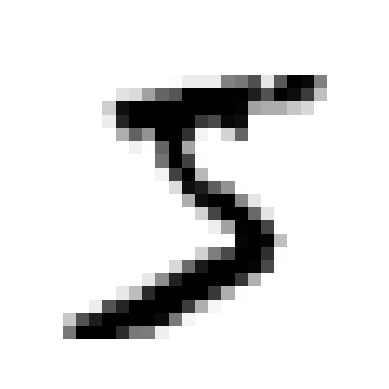

In [15]:
import matplotlib.pyplot as plt
def plot_digit(image_data) :
    image = image_data.reshape(28,28)
    plt.imshow(image,cmap='binary')
    plt.axis('off')

some_digit=X[0]
plot_digit(some_digit)
plt.show()

In [16]:
y[0]

'5'

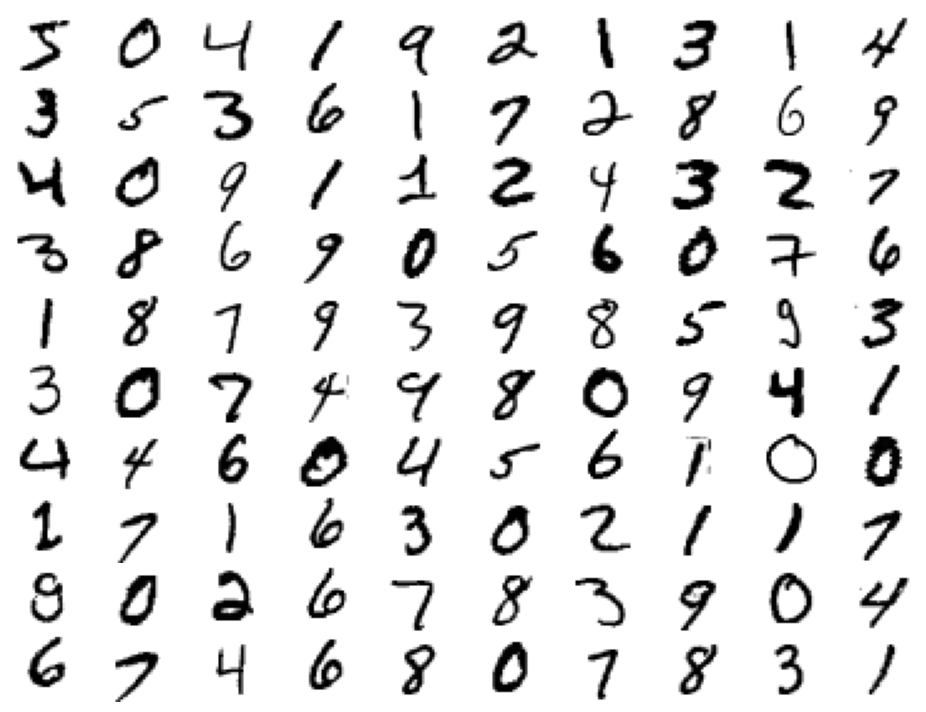

In [17]:
plt.figure(figsize=(12,9))
for idx , image_data in enumerate(X[:100]) :
    plt.subplot(10,10,idx+1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0,hspace=0)
plt.show()

In [18]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

Training a Binary Classifier

In [19]:
y_train_5=(y_train=='5')
y_test_5=(y_test=='5')

In [20]:
from sklearn.linear_model import SGDClassifier

sgd_clf= SGDClassifier(random_state=42)
sgd_clf.fit(X_train[:2000],y_train_5[:2000])

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [21]:
sgd_clf.predict([some_digit])

array([ True])

Performance measures

In [22]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is not
                                       # already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


Confusion Matrix

In [24]:
from sklearn.model_selection import cross_val_predict
y_train_pred= cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [26]:
y_train_perfect_predictions=y_train_5
confusion_matrix(y_train_5,y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

Precision and Recall

In [27]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)  # == 3530 / (687 + 3530)
cm[1,1]/(cm[0,1]+cm[1,1])

np.float64(0.8370879772350012)

In [28]:
from sklearn.metrics import precision_score, recall_score

recall_score(y_train_5, y_train_pred)  # == 3530 / (1891 + 3530)
cm[1, 1] / (cm[1, 0] + cm[1, 1])

np.float64(0.6511713705958311)

Precision/Recall Trade-off

In [29]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([487284.08964848])

In [30]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [31]:
threshold =8000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

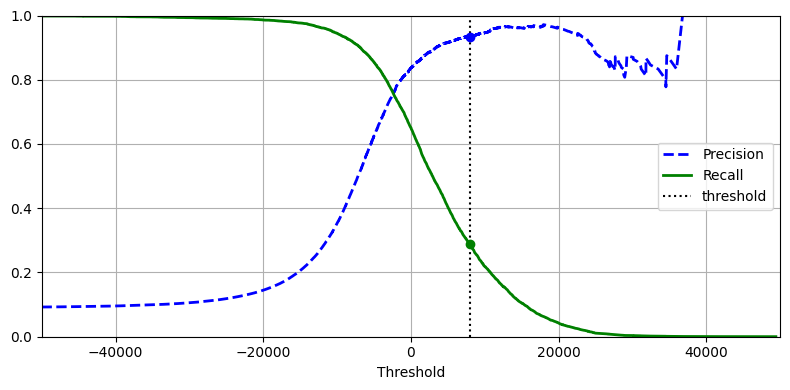

In [32]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds =precision_recall_curve(y_train_5,y_scores)


plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

In [33]:
import numpy as np 
threshold_90_precision=thresholds[np.argmax(precisions>=0.9)]
y_train_pred_90=(y_scores >= threshold_90_precision)


In [34]:
display(precision_score(y_train_5,y_train_pred_90))
display(recall_score(y_train_5,y_train_pred_90))


0.9000345901072293

0.4799852425751706

The ROC Curve

In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

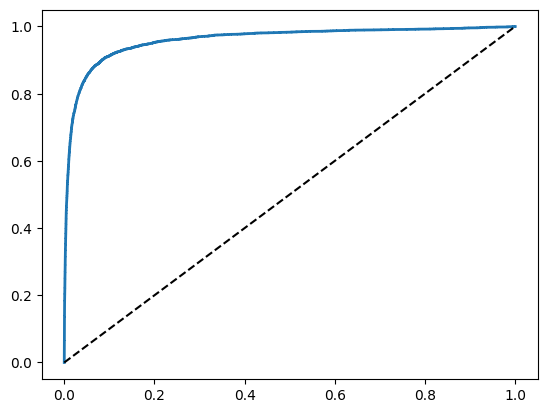

In [36]:
def plot_roc_curve(fpr,tpr,label=None):
    plt.plot(fpr, tpr, linewidth=2,label=label)
    plt.plot([0,1],[0,1],'k--')

plot_roc_curve(fpr,tpr)
plt.show()

In [37]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

0.9604938554008616

In [38]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

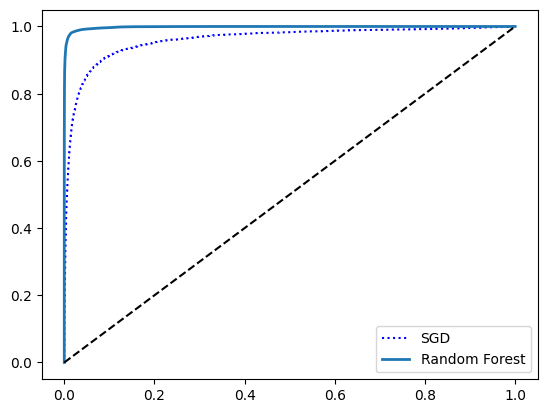

In [39]:
y_scores_forest=y_probas_forest[:,1]
fpr_forest,tpr_forest, thresholds_forest =roc_curve(y_train_5,y_scores_forest)

plt.plot(fpr,tpr,'b:',label='SGD')
plot_roc_curve(fpr_forest,tpr_forest,"Random Forest" )
plt.legend(loc="lower right")
plt.show()

In [40]:
roc_auc_score(y_train_5,y_scores_forest)

0.9983436731328145

Multiclass Classification

In [41]:
from sklearn.svm import SVC

svm_clf=SVC()
svm_clf.fit(X_train,y_train)
svm_clf.predict([some_digit])


array(['5'], dtype=object)

In [42]:
some_digit_scores=svm_clf.decision_function([some_digit])
some_digit_scores

array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [43]:
np.argmax(some_digit_scores)

np.int64(5)

In [44]:
svm_clf.classes_
svm_clf.classes_[5]

'5'

In [45]:
from sklearn.multiclass import OneVsRestClassifier
ovr_clf=OneVsRestClassifier(SVC())
ovr_clf.fit(X_train[:1000],y_train[:1000])

,estimator,SVC()
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


In [46]:
ovr_clf.predict([some_digit])
len(ovr_clf.estimators_)

10

In [47]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train[:1000], y_train[:1000])
sgd_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [48]:
sgd_clf.decision_function([some_digit]).round()

array([[-6049582., -6138036., -3886281.,  -604692., -6948311.,   914498.,
        -6855667., -3866146., -4016434., -3209137.]])

In [49]:
cross_val_score(sgd_clf, X_train[:1000], y_train[:1000], cv=3, scoring="accuracy")

array([0.83233533, 0.82882883, 0.79279279])

In [50]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled[:1000], y_train[:1000], cv=3, scoring="accuracy")

array([0.84431138, 0.81381381, 0.77177177])

Error Analysis

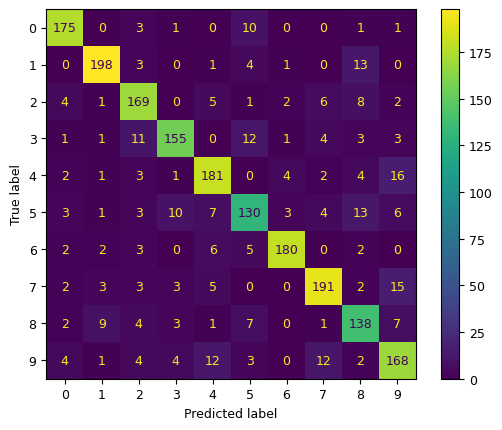

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled[:2000], y_train[:2000], cv=3)
plt.rc('font', size=9)  # extra code – make the text smaller
ConfusionMatrixDisplay.from_predictions(y_train[:2000], y_train_pred[:2000])
plt.show()

Multilabel Classification

In [55]:
from sklearn.neighbors import KNeighborsClassifier
y_train_large= (y_train >= '7' )
y_train_odd=(y_train.astype('int8') % 2==1)
y_multilabel=np.c_[y_train_large,y_train_odd]

knn_clf=KNeighborsClassifier()
knn_clf.fit(X_train[:2000],y_multilabel[:2000])

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [56]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [59]:

from sklearn.metrics import f1_score
y_train_knn_pred = cross_val_predict(knn_clf, X_train[:2000], y_multilabel[:2000], cv=3)
f1_score(y_multilabel[:2000], y_train_knn_pred[:2000], average="macro")

0.9176605556691428

Multioutput Classification

In [62]:
noise=np.random.randint(0,100,(len(X_train),784))
X_train_mod=X_train+noise
noise=np.random.randint(0,100,(len(X_test),784))
X_test_mod=X_test+noise
y_train_mod =X_train
y_test_mod=X_test

In [64]:
knn_clf.fit(X_train_mod[:2000],y_train_mod[:2000])
clean_digit=knn_clf.predict([X_test_mod[0]])

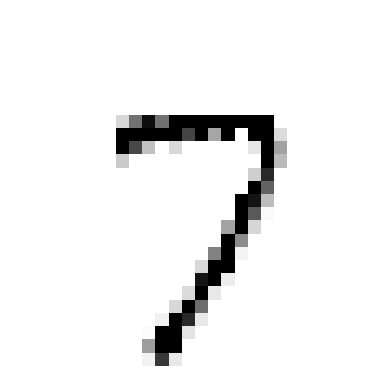

In [65]:
plot_digit(clean_digit)